# M&A Prediction from Pre-Announcement News Sentiment

**Goal:** Predict whether a company will be acquired based on news coverage patterns *before* the public announcement.

### Why news instead of stock prices?
- News signals can surface strategic shifts, financial stress, or industry consolidation trends before markets react
- Free, scalable data source via GDELT + SEC EDGAR full-text search (no API key required)

### Scope: large ($1B+) deals only
`ma_events.csv` is now built from two S&P Global exports pre-filtered to **deal value >= $1B**,
spanning **2016-2026** (`code/clean_ma_events.py`, `--min-deal-value-usd 1e9`). Restricting to large
deals means targets are much more likely to be well-covered public companies, which is exactly the
regime where name-based news search has enough recall to be informative.

### Pipeline
```
ma_events.csv   ->   GDELT + EDGAR    ->  local persistent cache  ->  NLP feature layer   ->  models
($1B+, 2016-26)     (by company name)    data/raw/news/*.csv        VADER + FinBERT +      (LogReg, RF)
                                                                     TF-IDF log-odds +
                                                                     NMF topics
```

News is no longer scraped inline in this notebook. `code/download_news_ma_events.py` fetches GDELT +
SEC EDGAR articles for a sample of events and appends them to a **local, resumable, gitignored cache**
(`data/raw/news/ma_event_news.csv`) — re-running it only fetches events/windows not already cached, so
the (slow, rate-limited) scraping cost is paid once. This notebook just loads that cache. Google News
RSS was dropped from the source mix: it has no historical date filter, so it cannot serve the
2016-2025 announcement windows used here.

### Experimental Design
| Sample | Company | News Window | Label |
|--------|---------|-------------|-------|
| Positive | M&A target | 90 -> 7 days before announcement | 1 |
| Negative | Same company | 270 -> 187 days before announcement | 0 |

The **blackout of 7 days** avoids leakage from deal rumor news appearing right before announcement.
The **180-day shift** creates a "quiet period" baseline for the same company.

### Deeper NLP (this pass)
The first pass used only VADER (a fixed sentiment lexicon) and a hand-written M&A keyword regex. This
pass adds three model-based / data-driven layers, still with **no generative LLM**:
1. **FinBERT** (`ProsusAI/finbert`) — a finance-tuned BERT classifier — for sentence-level sentiment, replacing the general-purpose VADER lexicon with one trained on financial text.
2. **TF-IDF + log-odds ratio** (Monroe et al. informative-prior log-odds) — discovers which words/phrases actually separate the *pre* window from the *baseline* window in this corpus, instead of relying on a fixed keyword list.
3. **NMF topic modeling** — unsupervised topic decomposition of the headline corpus, giving each event-window a topic-loading vector (e.g. "regulatory/antitrust", "earnings", "activist/strategic review").

In [50]:
import subprocess, sys
for pkg in ['vaderSentiment', 'scikit-learn', 'transformers', 'torch']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✓ Dependencies ready')

✓ Dependencies ready


In [51]:
import os, re, time, json, warnings, random, sys
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import NMF
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
CODE_DIR     = PROJECT_ROOT / 'code'
EVENTS_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'events' / 'ma_events.csv'
NEWS_CACHE   = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news.csv'   # built by download_news_ma_events.py
FEATURES_OUT = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features.csv'

# Reuse the same helpers the standalone scraper uses, so window definitions can't drift
sys.path.insert(0, str(CODE_DIR))
from download_news_ma_events import clean_name, get_window_dates

# ── Experiment config (must match the scraping run in download_news_ma_events.py) ──
LOOKBACK_DAYS   = 90    # total lookback window length
BLACKOUT_DAYS   = 7     # exclude last N days before announcement
NEGATIVE_SHIFT  = 180   # shift back for negative samples
RANDOM_SEED     = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✓ Imports complete')

✓ Imports complete


## 1. Data Overview

In [52]:
events = pd.read_csv(EVENTS_PATH, parse_dates=['announcement_date', 'close_date'])

print(f'Total M&A events:             {len(events):>8,}')
print(f'Date range:                   {events["announcement_date"].min().date()} → {events["announcement_date"].max().date()}')
print(f'Events with target ticker:    {events["target_ticker"].notna().sum():>8,}  ({events["target_ticker"].notna().mean():.1%})')
print(f'Events with acquirer ticker:  {events["acquirer_ticker"].notna().sum():>8,}  ({events["acquirer_ticker"].notna().mean():.1%})')
print(f'Events with deal value:       {events["deal_value_usd"].notna().sum():>8,}')
print(f'\nStatus distribution:')
print(events['deal_status'].value_counts().to_string())

Total M&A events:                2,673
Date range:                   2016-06-24 → 2026-06-16
Events with target ticker:         113  (4.2%)
Events with acquirer ticker:     1,020  (38.2%)
Events with deal value:          2,673

Status distribution:
deal_status
Completed    2479
Announced     194


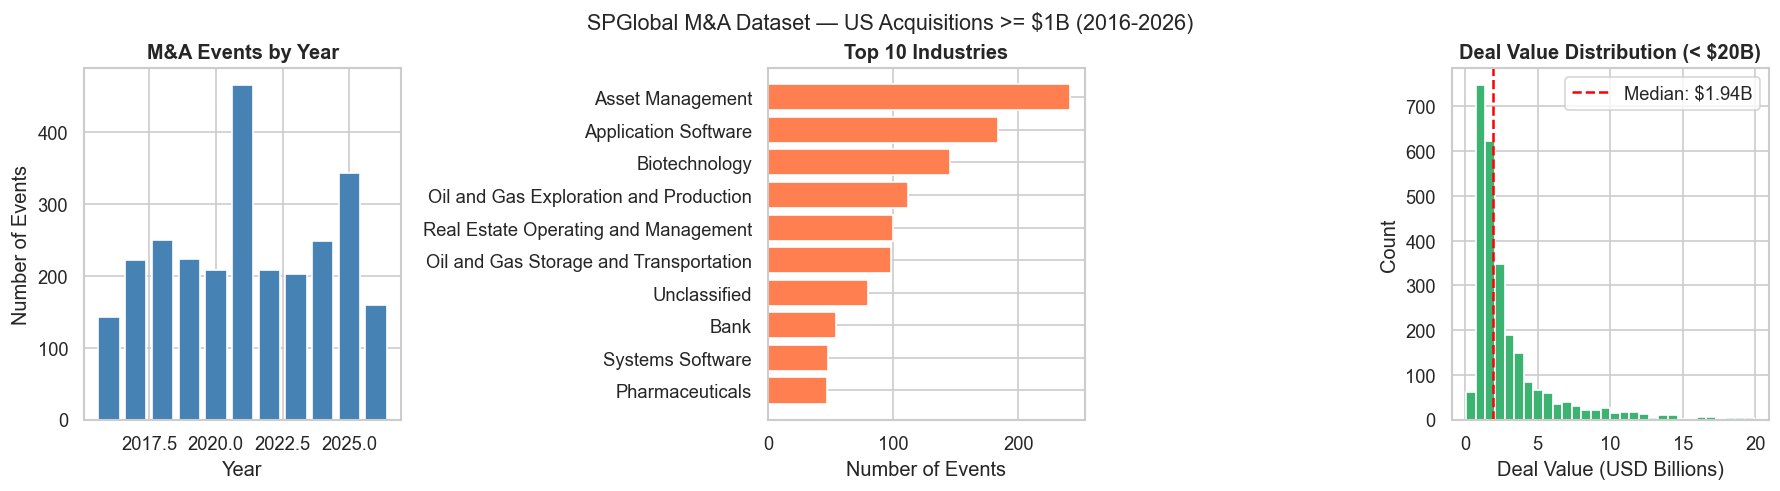

Deals with no ticker (private/unlisted targets): 2,560
→ Using company NAME for news search covers all 2,673 events


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Events per year
events['year'] = events['announcement_date'].dt.year
year_cnt = events['year'].value_counts().sort_index()
axes[0].bar(year_cnt.index, year_cnt.values, color='steelblue', edgecolor='white')
axes[0].set_title('M&A Events by Year', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Events')

# Top industries
top_ind = events['primary_industry'].value_counts().head(10)
axes[1].barh(top_ind.index[::-1], top_ind.values[::-1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Industries', fontweight='bold')
axes[1].set_xlabel('Number of Events')

# Deal value distribution (all events are already >= $1B by construction)
dv = events['deal_value_usd'].dropna() / 1e9
axes[2].hist(dv[dv < 20], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Deal Value Distribution (< $20B)', fontweight='bold')
axes[2].set_xlabel('Deal Value (USD Billions)')
axes[2].set_ylabel('Count')
axes[2].axvline(dv.median(), color='red', linestyle='--', label=f'Median: ${dv.median():.2f}B')
axes[2].legend()

plt.tight_layout()
plt.suptitle('SPGlobal M&A Dataset — US Acquisitions >= $1B (2016-2026)', fontsize=13, y=1.02)
plt.show()
print(f'Deals with no ticker (private/unlisted targets): {events["target_ticker"].isna().sum():,}')
print(f'→ Using company NAME for news search covers all {len(events):,} events')

## 2. News Data (from local persistent cache)

News is fetched by the standalone, resumable script `code/download_news_ma_events.py`, **not** inline
in this notebook. It queries two complementary free, date-filterable sources per event window:

| Source | Coverage | Date Filter | Auth |
|--------|----------|-------------|------|
| **GDELT** | Global news media | ✓ date range | none |
| **SEC EDGAR full-text search** | 8-K / SC-TO / SC-13D / SC-13G / DEFM14A filings mentioning the company | ✓ date range | none |

(Google News RSS was dropped — it has no historical date filter, so it cannot serve 2016-2025
announcement windows and would only burn request budget.)

Each run samples events from `ma_events.csv` ($1B+, 2016-2026) and scrapes two 90-day windows:
- **`pre`** (label=1): `[announcement − 97d, announcement − 7d]`
- **`baseline`** (label=0): the same window shifted back 180 days — a "quiet period" for the same company

Results append to `data/raw/news/ma_event_news.csv` (gitignored, regenerable per `DATA.md`).
**Re-running the script only fetches (transaction_id, window) pairs not already in the cache** — safe
to stop, resume, or top up with more events at any time without re-paying GDELT's rate limit.

```bash
# from the repo root, run more coverage whenever needed:
python code/download_news_ma_events.py --n-events 300 --seed 42
```

The cells below just **load** whatever is currently in the cache.

In [54]:
# Reuse the exact same fetchers the standalone scraper uses (single source of truth for
# query construction / rate limiting), for optional ad-hoc spot-checks in this notebook.
from download_news_ma_events import fetch_gdelt, fetch_edgar, RateLimiter

MA_KW_RE = re.compile(
    r'\b(merger|acqui|takeover|buyout|buy.?out|strategic|bid|offer|'
    r'private equity|stake|transaction|bought|sold|purchase)\b',
    re.IGNORECASE
)

print('✓ Scrapers imported from code/download_news_ma_events.py')
print('  GDELT:     free, historical, exact-phrase -> any-language fallback')
print('  SEC EDGAR: free, full-text search over M&A-relevant filings (8-K/SC-TO/13D/13G/DEFM14A)')

✓ Scrapers imported from code/download_news_ma_events.py
  GDELT:     free, historical, exact-phrase -> any-language fallback
  SEC EDGAR: free, full-text search over M&A-relevant filings (8-K/SC-TO/13D/13G/DEFM14A)


In [55]:
# ── Connectivity test + demo ──────────────────────────────────────────────
limiter = RateLimiter(1.2)

print('Testing GDELT connectivity...')
test_arts = fetch_gdelt(limiter, 'Microsoft', '2023-01-01', '2023-01-31', max_records=3)
if test_arts:
    print(f'✓ GDELT reachable — {len(test_arts)} articles for Microsoft (2023-01)')
else:
    print('✗ GDELT returned 0 — possible connectivity issue or VPN block.')

print()

# Step 2: demo with a large ($1B+) target from the event set
demo_event = events[events['target_name'].notna()].iloc[100]
demo_name  = demo_event['target_name']
demo_ann   = pd.Timestamp(demo_event['announcement_date'])
demo_start, demo_end = get_window_dates(demo_ann, 'pre', LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)

print(f'Demo company: {demo_name}   (deal value ${demo_event["deal_value_usd"]/1e9:.1f}B)')
print(f'Announced:    {demo_ann.date()}')
print(f'Window:       {demo_start} → {demo_end}')
print(f'Query name:   "{clean_name(demo_name)}"')
print()

gdelt_arts = fetch_gdelt(limiter, demo_name, demo_start, demo_end)
edgar_arts = fetch_edgar(demo_name, demo_start, demo_end)

print(f'GDELT:  {len(gdelt_arts):3d} articles')
print(f'EDGAR:  {len(edgar_arts):3d} filings')

for a in (gdelt_arts + edgar_arts)[:4]:
    print(f"  [{a['source']:6s}][{a.get('date','------')[:8]}] {a['title'][:75]}")

Testing GDELT connectivity...
✓ GDELT reachable — 3 articles for Microsoft (2023-01)

Demo company: Two Harbors Investment Corp.   (deal value $1.3B)
Announced:    2026-03-19
Window:       2025-12-12 → 2026-03-12
Query name:   "Two Harbors Investment"

GDELT:   27 articles
EDGAR:   20 filings
  [gdelt ][20260308] Head to Head Comparison : Two Harbors Investments ( NYSE : TWO ) & MFA Fina
  [gdelt ][20260303] A Look At Two Harbors Investment ( TWO ) Valuation After Recent Share Price
  [gdelt ][20260301] UWM Holdings CEO Sells Nearly 2M Shares For $9M
  [gdelt ][20260301] UWM Holdings CEO Sells 1 . 27M Shares for $6 . 5 Million


In [56]:
def load_cache() -> pd.DataFrame:
    if NEWS_CACHE.exists():
        return pd.read_csv(NEWS_CACHE, dtype=str).fillna('')
    return pd.DataFrame(columns=['transaction_id', 'window', 'label', 'company_name', 'title', 'date', 'domain', 'source', 'url'])

print('✓ Cache loader defined —', NEWS_CACHE.relative_to(PROJECT_ROOT))

✓ Cache loader defined — data/raw/news/ma_event_news.csv


In [57]:
# ── Preview the event pool the standalone scraper targets ─────────────────
# (mirrors select_events() in code/download_news_ma_events.py)
events_pool = events[
    (events['target_name'].notna()) &
    (events['deal_status'].isin(['Completed', 'Announced']))
].copy()

cache_preview = load_cache()
cached_ids = set(cache_preview['transaction_id']) if not cache_preview.empty else set()

print(f'Eligible $1B+ events (2016-2026):  {len(events_pool):,}')
print(f'Events already in local cache:     {len(cached_ids):,}')
print(f'Not yet scraped:                   {len(events_pool) - len(cached_ids):,}')

Eligible $1B+ events (2016-2026):  2,673
Events already in local cache:     523
Not yet scraped:                   2,150


In [58]:
# ── Load the persistent news cache (built by code/download_news_ma_events.py) ─────────
# No inline scraping here anymore — this just loads whatever has been cached so far.
# To add more coverage (safe to re-run, resumes from where it left off):
#     python code/download_news_ma_events.py --n-events 300

cache_df = load_cache()
if cache_df.empty:
    raise RuntimeError(
        'No cached news found. From the repo root, run:\n'
        '  python code/download_news_ma_events.py --n-events 300\n'
        'then re-run this cell.'
    )

print(f'✓ Cache: {len(cache_df):,} rows  ({cache_df["transaction_id"].nunique()} events)')
articles_only = cache_df[cache_df['title'] != '']
print(f'  Articles with text: {len(articles_only):,}')
print(f'  Events with ≥1 article: {articles_only["transaction_id"].nunique()}')
if 'source' in articles_only.columns:
    print(f'\n  Breakdown by source:')
    print(articles_only['source'].value_counts().to_string())

✓ Cache: 10,222 rows  (523 events)
  Articles with text: 9,611
  Events with ≥1 article: 258

  Breakdown by source:
source
gdelt    6082
edgar    3529


## 3. NLP Layer 1 — VADER Sentiment (baseline)

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based, general-purpose lexicon
scorer. It's fast and needs no training data, but it wasn't built for financial text — words like
"aggressive" or "leverage" carry finance-specific connotations VADER doesn't know about. We keep it
as a fast baseline and then add deeper layers below (FinBERT, data-driven terms, momentum, filings).

**Source split (important fix):** SEC EDGAR "articles" in the cache are not prose — they're
auto-generated strings like `[8-K] COMPANY NAME (CIK 0001234) filed 2020-08-11`. Scoring that string
with a sentiment model is meaningless noise (it also pollutes the TF-IDF/topic layers below with
company-identity boilerplate — see §3c/§3d). So **all sentiment/text-mining NLP layers (VADER,
FinBERT, log-odds terms, NMF topics) run on GDELT headlines only**; EDGAR filings still carry real
signal, just structured, and are turned into filing-type/frequency features in §3e instead.

- Returns a **compound score** in [-1, 1]: negative → positive
- We also flag any headline matching a fixed M&A keyword regex (`MA_KW_RE`)

**Noise filter (fix):** GDELT is queried by exact company name, which also pulls in algorithmically-generated financial spam (13F/holdings-change bots, price-target/rating bots, market-research-report mills) that fires for every public company on a schedule, independent of M&A activity. A content-based regex (not label-conditioned) drops these before scoring.

In [59]:
sia = SentimentIntensityAnalyzer()

def score(title: str) -> dict:
    if not title or not str(title).strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0, 'has_ma_kw': 0}
    s = sia.polarity_scores(str(title))
    s['has_ma_kw'] = int(bool(MA_KW_RE.search(str(title))))
    return s

news_df = load_cache()

# ── Source split ────────────────────────────────────────────────────────
# EDGAR rows are auto-generated filing stubs, not prose (see markdown above) -- route
# them to structured filing-type features in §3e instead of sentiment scoring.
edgar_df = news_df[(news_df['source'] == 'edgar') & (news_df['title'].str.strip() != '')].copy()
gdelt_df = news_df[(news_df['source'] == 'gdelt') & (news_df['title'].str.strip() != '')].copy()

# ── Institutional/analyst-bot noise filter ──────────────────────────────────
# GDELT's "exact company name" query pulls in a lot of algorithmically-generated financial
# content -- 13F/holdings-change bots ("Sells 47,684 Shares of..."), analyst price-target/
# rating bots, and market-research-report spam ("Global ... Market 2020 by Technology"). These
# fire for every public company on a schedule regardless of M&A activity, so they dilute
# rather than inform the corpus. Flag+drop them with a template regex (content-based, applied
# identically to both windows -- not conditioned on label).
NOISE_RE = re.compile(
    r'('
    r'\bShares\b.{0,40}\b(Sold|Bought|Acquired|Cut|Lowered|Raised|Boosted|Purchased)\b|'
    r'\b(Sells|Buys|Acquires|Cuts|Lowers|Raises|Boosts|Purchases)\b.{0,40}\bShares\b|'
    r'\bHoldings (in|of)\b|\bPosition (in|of)\b|\bStake (in|of)\b|'
    r'\bPosition (Lowered|Raised|Boosted|Cut)\b|'
    r'\bPrice Target\b|\bPT from\b|\bAverage (Price )?Target\b|'
    r'\bRating (Upgraded|Downgraded|Reiterated|Lowered|Raised)\b|'
    r'\bShort Interest\b|\bInstitutional Investor\b|\bHedge Fund\b|'
    r'\bAverage Recommendation\b|\bModerate Buy\b|\b13F\b|'
    r'\bQ[1-4]\s?20\d\d Earnings\b|\bEarnings (Call )?Transcript\b|\bEarnings Snapshot\b|'
    r'\bMarket (Report|Size|Share|Growth|Trends|Forecast|Challenges|Outlook)\b|'
    r'\bGlobal Market\b|\bIndustry Forecast\b|\bTop Players\b|\bMarket 20\d\d\b|'
    r'\bMakes New Investment\b|\bTakes .{0,20}Position\b'
    r')',
    re.IGNORECASE,
)
is_noise = gdelt_df['title'].str.contains(NOISE_RE, regex=True)
print(f'Institutional/analyst-bot noise filter: dropping {is_noise.sum():,} of {len(gdelt_df):,} '
      f'GDELT headlines ({is_noise.mean():.1%}, balanced across windows: '
      f'{gdelt_df.groupby("window").apply(lambda g: g["title"].str.contains(NOISE_RE, regex=True).mean()).to_dict()})')
valid = gdelt_df[~is_noise].copy()

scores  = valid['title'].apply(score)
sent_df = pd.concat([valid.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
sent_df['label'] = sent_df['label'].astype(int)

print(f'\nScored {len(sent_df):,} GDELT headlines (of {len(news_df):,} cached rows; '
      f'{len(edgar_df):,} EDGAR filings routed to structured features in §3e instead)')
print('\nMean sentiment by window (GDELT news only, noise-filtered):')
print(sent_df.groupby('window')[['compound', 'pos', 'neg', 'has_ma_kw']].mean().round(4))

Institutional/analyst-bot noise filter: dropping 610 of 6,082 GDELT headlines (10.0%, balanced across windows: {'baseline': 0.09867549668874172, 'pre': 0.10189418680600915})

Scored 5,472 GDELT headlines (of 10,222 cached rows; 3,529 EDGAR filings routed to structured features in §3e instead)

Mean sentiment by window (GDELT news only, noise-filtered):
          compound     pos     neg  has_ma_kw
window                                       
baseline    0.1004  0.0919  0.0371     0.0220
pre         0.0871  0.0836  0.0405     0.0287


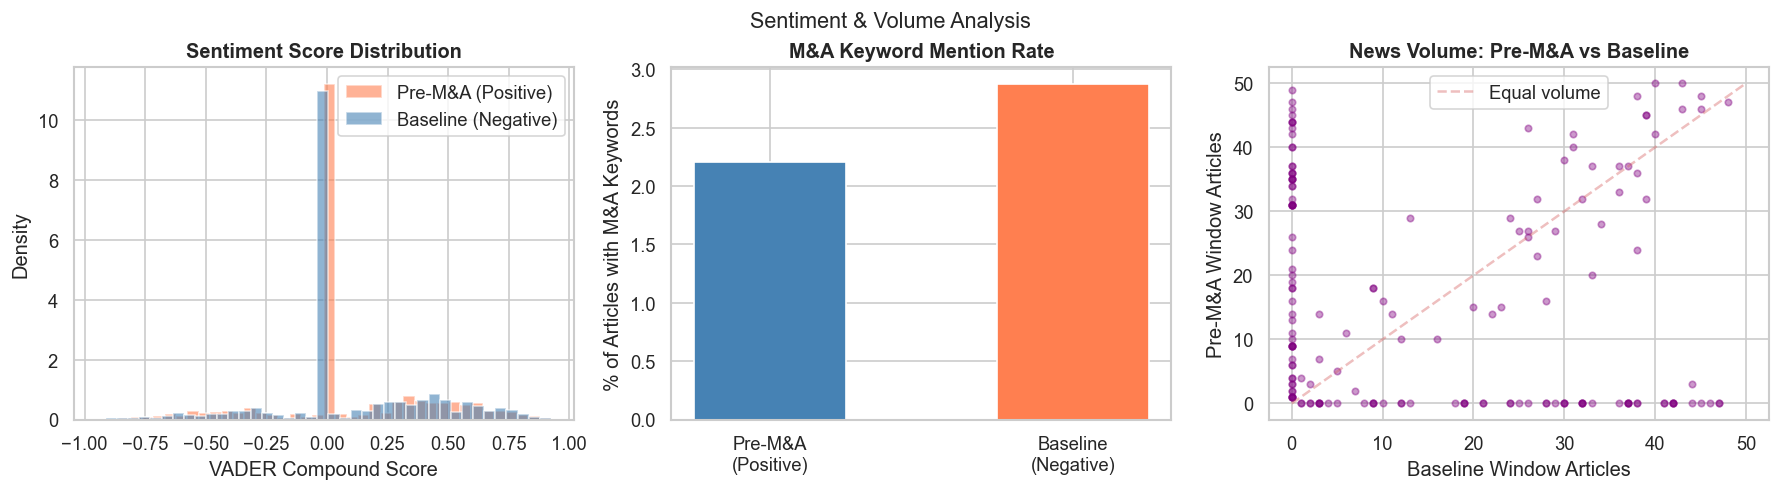

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment distribution
for window, color, lbl in [('pre', 'coral', 'Pre-M&A (Positive)'),
                             ('baseline', 'steelblue', 'Baseline (Negative)')]:
    d = sent_df[sent_df['window'] == window]['compound']
    axes[0].hist(d, bins=40, alpha=0.6, color=color, label=lbl, density=True)
axes[0].set_title('Sentiment Score Distribution', fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# M&A keyword rate
kw_rate = sent_df.groupby('window')['has_ma_kw'].mean() * 100
colors_bar = ['coral' if w == 'pre' else 'steelblue' for w in kw_rate.index]
axes[1].bar(kw_rate.index, kw_rate.values, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('M&A Keyword Mention Rate', fontweight='bold')
axes[1].set_ylabel('% of Articles with M&A Keywords')
axes[1].set_xticklabels(['Pre-M&A\n(Positive)', 'Baseline\n(Negative)'])

# Article volume comparison
cnt = sent_df.groupby(['transaction_id', 'window']).size().unstack(fill_value=0)
if 'pre' in cnt.columns and 'baseline' in cnt.columns:
    axes[2].scatter(cnt['baseline'], cnt['pre'], alpha=0.4, color='purple', s=15)
    mx = cnt.max().max()
    axes[2].plot([0, mx], [0, mx], 'r--', alpha=0.4, label='Equal volume')
    axes[2].set_title('News Volume: Pre-M&A vs Baseline', fontweight='bold')
    axes[2].set_xlabel('Baseline Window Articles')
    axes[2].set_ylabel('Pre-M&A Window Articles')
    axes[2].legend()

plt.tight_layout()
plt.suptitle('Sentiment & Volume Analysis', fontsize=13, y=1.02)
plt.show()

## 3b. NLP Layer 2 — FinBERT (finance-tuned sentiment)

VADER is a general lexicon; it has no notion that "leverage," "activist," or "antitrust" carry
different weight in financial headlines than in everyday text. **FinBERT** (`ProsusAI/finbert`) is a
BERT model fine-tuned on financial text for 3-class sentiment (positive/negative/neutral). It runs
fully locally (no API calls, no generative LLM) via `transformers`.

We score every cached headline and define `finbert_compound = P(positive) − P(negative)`, the same
shape as VADER's compound score, so the two are directly comparable feature-by-feature.

In [61]:
from transformers import pipeline

print('Loading FinBERT (ProsusAI/finbert) — local, runs once per session...')
finbert = pipeline('text-classification', model='ProsusAI/finbert', top_k=None, truncation=True, device=-1)

def finbert_score_batch(titles: list[str], batch_size: int = 32) -> pd.DataFrame:
    rows = []
    texts = [t if t and str(t).strip() else '.' for t in titles]
    for i in tqdm(range(0, len(texts), batch_size), desc='FinBERT'):
        out = finbert(texts[i:i + batch_size], batch_size=batch_size)
        for scores in out:
            rows.append({s['label']: s['score'] for s in scores})
    return pd.DataFrame(rows)

finbert_scores = finbert_score_batch(sent_df['title'].tolist())
sent_df['finbert_positive'] = finbert_scores['positive'].values
sent_df['finbert_negative'] = finbert_scores['negative'].values
sent_df['finbert_neutral']  = finbert_scores['neutral'].values
sent_df['finbert_compound'] = sent_df['finbert_positive'] - sent_df['finbert_negative']

print(f'\nScored {len(sent_df):,} headlines with FinBERT')
print('\nMean FinBERT sentiment by window:')
print(sent_df.groupby('window')[['finbert_compound', 'finbert_positive', 'finbert_negative']].mean().round(4))
print('\nMean VADER vs FinBERT compound by window (for comparison):')
print(sent_df.groupby('window')[['compound', 'finbert_compound']].mean().round(4))

Loading FinBERT (ProsusAI/finbert) — local, runs once per session...


FinBERT: 100%|██████████| 171/171 [00:36<00:00,  4.63it/s]


Scored 5,472 headlines with FinBERT

Mean FinBERT sentiment by window:
          finbert_compound  finbert_positive  finbert_negative
window                                                        
baseline            0.0827            0.2145            0.1318
pre                 0.0824            0.2107            0.1283

Mean VADER vs FinBERT compound by window (for comparison):
          compound  finbert_compound
window                              
baseline    0.1004            0.0827
pre         0.0871            0.0824


## 3c. NLP Layer 3 — TF-IDF + Log-Odds Distinctive Terms (data-driven, not hand-written)

`MA_KW_RE` above is a fixed keyword list someone wrote down in advance. Instead, we let the corpus
tell us which words actually separate the *pre*-announcement window from the *baseline* window,
using the **informative-Dirichlet-prior log-odds-ratio** (Monroe, Colaresi & Quinn, 2008) — a
standard way to rank terms by class-distinctiveness that corrects for frequency (rare words don't
spuriously dominate) better than a raw log-odds or chi-square test would.

For each unigram/bigram $w$: $z_w = \dfrac{\delta_w}{\sqrt{\mathrm{Var}(\delta_w)}}$ where $\delta_w$
is the prior-smoothed log-odds of $w$ appearing in *pre* vs *baseline* headlines. Large $|z_w|$ = more
distinctive.

**Company-name masking (fix):** the *pre* and *baseline* windows are the same company at two points
in time, so every headline in both windows already mentions that company's name — a prolific company
(lots of press either way) would otherwise dominate the term counts with its own name/ticker, which
is a company identifier, not a generalizable M&A signal. Before vectorizing, each headline has its own
company's name tokens (from `clean_name`) blanked out, so the surviving distinctive terms have to be
genuinely shared content words across companies.

**Caveat (by design, not an oversight):** the terms below are still mined from the *entire* cached corpus,
across all events. Using the resulting `distinctive_term_ratio` feature in the classifier is therefore
not strictly train/test-isolated — it's an exploratory feature, flagged here and again in the
Limitations section. A leakage-safe version would refit this per CV fold.

In [62]:
TOKEN_PATTERN = r"(?u)\b[a-zA-Z]{3,}\b"

# ── Mask each headline's own company name out before vectorizing ──────────
# Without this, "distinctive terms" are dominated by which *company* happens to have
# lots of coverage in one window (e.g. a company name like "avidity" or "stericycle")
# rather than genuinely cross-company M&A language.
from functools import lru_cache

@lru_cache(maxsize=None)
def _company_mask_pattern(company_name: str):
    words = [w for w in clean_name(company_name).split() if len(w) >= 3]
    if not words:
        return None
    return re.compile(r'\b(' + '|'.join(re.escape(w) for w in words) + r')\b', re.IGNORECASE)

def _mask_company(row):
    pat = _company_mask_pattern(row['company_name'])
    return pat.sub(' ', str(row['title'])) if pat else str(row['title'])

sent_df['title_masked'] = sent_df.apply(_mask_company, axis=1)

count_vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                             token_pattern=TOKEN_PATTERN)
X_counts = count_vec.fit_transform(sent_df['title_masked'])
vocab = count_vec.get_feature_names_out()

pre_mask  = (sent_df['window'] == 'pre').values
base_mask = (sent_df['window'] == 'baseline').values

counts_pre  = np.asarray(X_counts[pre_mask].sum(axis=0)).ravel()
counts_base = np.asarray(X_counts[base_mask].sum(axis=0)).ravel()
n_pre, n_base = counts_pre.sum(), counts_base.sum()

# Background (informative) prior: each word's overall frequency, scaled to a modest total pseudo-count
alpha0 = 1000.0
background = (counts_pre + counts_base) / (counts_pre.sum() + counts_base.sum())
alpha_w = background * alpha0

def log_odds_z(y_i, y_j, n_i, n_j, a_w, a0):
    delta = (np.log((y_i + a_w) / (n_i + a0 - y_i - a_w))
             - np.log((y_j + a_w) / (n_j + a0 - y_j - a_w)))
    variance = 1.0 / (y_i + a_w) + 1.0 / (y_j + a_w)
    return delta / np.sqrt(variance)

z_scores = log_odds_z(counts_pre, counts_base, n_pre, n_base, alpha_w, alpha0)

logodds_df = pd.DataFrame({
    'term': vocab, 'z_score': z_scores, 'count_pre': counts_pre, 'count_baseline': counts_base,
}).sort_values('z_score', ascending=False)

print('Top 15 terms distinctive of the PRE-M&A window (company names masked out):')
print(logodds_df.head(15)[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))
print('\nTop 15 terms distinctive of the BASELINE (quiet-period) window:')
print(logodds_df.tail(15).sort_values('z_score')[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))

SIG_Z = 2.0
distinctive_terms = logodds_df.loc[logodds_df['z_score'].abs() >= SIG_Z, 'term'].tolist()
print(f'\n{len(distinctive_terms)} terms pass |z| >= {SIG_Z} and will feed `distinctive_term_ratio`')

_distinctive_pattern = (
    re.compile(r'\b(' + '|'.join(re.escape(t) for t in distinctive_terms) + r')\b', re.IGNORECASE)
    if distinctive_terms else None
)
sent_df['has_distinctive_term'] = sent_df['title_masked'].apply(
    lambda t: int(bool(_distinctive_pattern.search(str(t)))) if _distinctive_pattern else 0
)

Top 15 terms distinctive of the PRE-M&A window (company names masked out):
              term  z_score  count_pre  count_baseline
          vaccines 4.043256         47              12
companies vaccines 4.018216         45              11
              hold 3.445117         28               5
              spac 3.424971         24               2
             women 3.215941         37              12
              self 3.191898         21               2
           trailer 3.110132         20               1
            delays 3.108543         20               2
            forbes 3.108543         20               2
            merger 3.092214         21               3
               feb 2.958916         18               1
              star 2.951584         31              10
            friday 2.943352         26               7
          closings 2.921957         22               0
              wars 2.879069         17               1

Top 15 terms distinctive of the BASELINE (qu

## 3d. NLP Layer 4 — NMF Topic Modeling

Sentiment alone collapses a headline to one number. **Topic modeling** captures *what a headline is
about* — e.g. an antitrust/regulatory story reads very differently from an earnings-beat story, even
at similar sentiment. We fit **NMF** (non-negative matrix factorization) on TF-IDF vectors of the
**company-name-masked** headline corpus (same masking as §3c, for the same reason — otherwise topics
are company clusters, not content clusters) — the standard, fast, sklearn-native alternative to LDA
for short text — and use each headline's topic-loading vector as additional features, aggregated
(mean) per event-window.

In [63]:
N_TOPICS = 8

tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                             token_pattern=TOKEN_PATTERN)
X_tfidf = tfidf_vec.fit_transform(sent_df['title_masked'])

nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=RANDOM_SEED, max_iter=400)
topic_loadings = nmf.fit_transform(X_tfidf)

topic_terms = tfidf_vec.get_feature_names_out()
print(f'NMF topics (top terms per topic, {N_TOPICS} topics, company names masked):')
for k in range(N_TOPICS):
    top_idx = nmf.components_[k].argsort()[::-1][:8]
    print(f'  Topic {k}: ' + ', '.join(topic_terms[i] for i in top_idx))

for k in range(N_TOPICS):
    sent_df[f'topic_{k}'] = topic_loadings[:, k]

NMF topics (top terms per topic, 8 topics, company names masked):
  Topic 0: watch, companies, watch companies, companies vaccines, vaccines, research, companies research, regulation
  Topic 1: market, global, growth, analysis, report, forecast, industry, billion
  Topic 2: stock, price, nyse, stock price, stock market, earnings, stock buy, today
  Topic 3: new, announces, data, business, mandalorian, trailer, solar, investment
  Topic 4: quarter, results, announces, financial, reports, earnings, financial results, second
  Topic 5: news, com, world, june, calendar, june news, calendar events, events june
  Topic 6: stocks, best, buy, stocks buy, fool, motley, motley fool, energy
  Topic 7: nasdaq, shares, rna, nasdaq rna, nyse, trading, head, sovo


## 3e. NLP Layer 5 — Within-Window Momentum & EDGAR Filing Structure

Two more signals that don't fit the "one sentiment number per headline" mold:

1. **Momentum inside the window.** Deal rumors typically build as the announcement approaches, then
   go dark during the 7-day blackout. If that's real, coverage inside the 90-day *pre* window should
   skew *late* (more articles, more sentiment drift, just before the blackout) relative to the
   quiet-period *baseline* window, which has no announcement to build toward. For each article we
   compute its relative position inside its own (`transaction_id`, `window`) date range (0 = window
   start, 1 = window end, using the official boundaries from `get_window_dates`, not just the min/max
   date actually observed), then aggregate two per-window features: `late_share` (fraction of articles
   in the final third of the window) and `sentiment_trend` (slope of VADER compound vs. relative
   position).
2. **EDGAR filing structure**, used as counts/rates instead of sentiment (see §3 — an EDGAR "headline"
   is an auto-generated filing stub, not prose). Filing types other than routine `8-K`s (e.g.
   `DEFM14A`, `SC-13D/G`, `SC-TO`) are direct regulatory evidence of an ownership change or merger
   process step, so filing-type mix is a legitimate, non-textual M&A signal.

In [64]:
## ── Momentum features (GDELT) ──────────────────────────────────────────────
sent_df = sent_df.merge(events[['transaction_id', 'announcement_date']], on='transaction_id', how='left')

def _window_bounds(row):
    start, end = get_window_dates(row['announcement_date'], row['window'],
                                   LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)
    return pd.Timestamp(start), pd.Timestamp(end)

_bounds = sent_df.apply(_window_bounds, axis=1, result_type='expand')
sent_df['_win_start'], sent_df['_win_end'] = _bounds[0], _bounds[1]
sent_df['_art_date'] = pd.to_datetime(sent_df['date'].str[:8], format='%Y%m%d', errors='coerce')

span = (sent_df['_win_end'] - sent_df['_win_start']).dt.days.clip(lower=1)
sent_df['rel_pos'] = ((sent_df['_art_date'] - sent_df['_win_start']).dt.days / span).clip(0, 1)

def momentum(group: pd.DataFrame) -> dict:
    g = group.dropna(subset=['rel_pos'])
    if len(g) < 3:
        return {'late_share': 0.0, 'sentiment_trend': 0.0}
    late_share = (g['rel_pos'] > (2 / 3)).mean()
    slope = np.polyfit(g['rel_pos'], g['compound'], 1)[0] if g['rel_pos'].nunique() > 1 else 0.0
    return {'late_share': late_share, 'sentiment_trend': slope}

momentum_df = (
    sent_df.groupby(['transaction_id', 'window'])
    .apply(lambda g: pd.Series(momentum(g)))
    .reset_index()
)
print(f'Momentum features computed for {len(momentum_df):,} event-windows')
print(momentum_df.groupby('window')[['late_share', 'sentiment_trend']].mean().round(4))

## ── EDGAR filing-structure features ─────────────────────────────────────────
FTYPE_RE = re.compile(r'^\[([^\]]+)\]')
edgar_df['filing_type'] = edgar_df['title'].apply(lambda t: (FTYPE_RE.match(t).group(1) if FTYPE_RE.match(t) else 'UNK'))
edgar_df['is_deal_filing'] = (edgar_df['filing_type'] != '8-K').astype(int)

def edgar_agg(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        return {'edgar_filing_count': 0, 'edgar_deal_filing_count': 0, 'edgar_deal_filing_ratio': 0.0}
    return {
        'edgar_filing_count':      n,
        'edgar_deal_filing_count': int(group['is_deal_filing'].sum()),
        'edgar_deal_filing_ratio': group['is_deal_filing'].mean(),
    }

edgar_feat_df = (
    edgar_df.groupby(['transaction_id', 'window'])
    .apply(lambda g: pd.Series(edgar_agg(g)))
    .reset_index()
)
print(f'\nEDGAR filing types seen: {edgar_df["filing_type"].value_counts().to_dict()}')
print(edgar_feat_df.groupby('window')[['edgar_filing_count', 'edgar_deal_filing_ratio']].mean().round(4))

Momentum features computed for 217 event-windows
          late_share  sentiment_trend
window                               
baseline      0.5769           0.0341
pre           0.5386           0.1257

EDGAR filing types seen: {'8-K': 3417, 'DEFM14A': 112}
          edgar_filing_count  edgar_deal_filing_ratio
window                                               
baseline             10.2096                   0.0527
pre                  10.3636                   0.0672


## 3f. NLP Layer 6 — Full-Article-Text Sentiment (partial, background-enriched)

Headlines are short and often uninformative on their own. `code/enrich_article_text.py` is a
separate, additive, resumable script that best-effort-fetches the body text for cached GDELT
article URLs (paragraph extraction, boilerplate stripped) into
`data/raw/news/ma_event_article_text.csv`. It runs independently of this notebook (long-running,
rate-limited, partial yield expected -- paywalls/dead links/anti-bot blocks are normal) and can
be topped up any time by re-running it; re-runs skip URLs already attempted.

This cell uses **whatever is in that cache right now** -- if it's still filling in, these
features cover fewer events than the headline-based ones and degrade gracefully to zero/absent
for the rest, same pattern as the other zero-coverage handling in §4.

In [65]:
FULLTEXT_CACHE = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_article_text.csv'

if FULLTEXT_CACHE.exists():
    fulltext_df = pd.read_csv(FULLTEXT_CACHE, dtype=str).fillna('')
    fulltext_df = fulltext_df[(fulltext_df['fetched'] == '1') & (fulltext_df['text'].str.len() > 200)]
else:
    fulltext_df = pd.DataFrame(columns=['url', 'transaction_id', 'window', 'fetched', 'char_count', 'text', 'error'])

print(f'Full-article-text enrichment cache: {len(fulltext_df):,} articles with usable body text '
      f'(background-fetched by code/enrich_article_text.py, best-effort, partial by design)')

if len(fulltext_df):
    ft = sent_df[['transaction_id', 'window', 'url']].merge(
        fulltext_df[['url', 'text']], on='url', how='inner'
    ).drop_duplicates(subset=['url'])

    ft['fulltext_vader_compound'] = ft['text'].apply(lambda t: sia.polarity_scores(t)['compound'])

    ft_finbert = finbert_score_batch(ft['text'].tolist())
    ft['fulltext_finbert_compound'] = (ft_finbert['positive'] - ft_finbert['negative']).values

    fulltext_feat_df = (
        ft.groupby(['transaction_id', 'window'])
        .agg(avg_fulltext_sentiment=('fulltext_vader_compound', 'mean'),
             avg_fulltext_finbert_compound=('fulltext_finbert_compound', 'mean'),
             fulltext_n=('url', 'count'))
        .reset_index()
    )
    print(f'Full-text sentiment computed for {len(fulltext_feat_df):,} event-windows '
          f'({fulltext_feat_df["transaction_id"].nunique()} events)')
    print(fulltext_feat_df.groupby('window')[['avg_fulltext_sentiment', 'avg_fulltext_finbert_compound']].mean().round(4))
else:
    fulltext_feat_df = pd.DataFrame(columns=['transaction_id', 'window', 'avg_fulltext_sentiment',
                                              'avg_fulltext_finbert_compound', 'fulltext_n'])
    print('No full-text data available yet -- these features will be all-zero/absent this run. '
          'Re-run this cell (and the ones below it) later once code/enrich_article_text.py has made progress.')

Full-article-text enrichment cache: 2,634 articles with usable body text (background-fetched by code/enrich_article_text.py, best-effort, partial by design)


FinBERT: 100%|██████████| 79/79 [04:00<00:00,  3.04s/it]

Full-text sentiment computed for 176 event-windows (135 events)
          avg_fulltext_sentiment  avg_fulltext_finbert_compound
window                                                         
baseline                  0.6969                         0.0471
pre                       0.6933                         0.0408


## 4. Feature Engineering

Aggregate article-level NLP outputs into **one feature vector per event-window**:

| Feature | Description | NLP layer |
|---------|-------------|-----------|
| `news_count` | Total GDELT articles in window | — |
| `avg_sentiment` / `std_sentiment` / `max_sentiment` / `min_sentiment` | VADER compound stats | VADER |
| `pos_ratio` / `neg_ratio` | Fraction positive / negative (VADER) | VADER |
| `ma_keyword_count` / `ma_keyword_ratio` | Fixed-regex M&A keyword hits | VADER baseline |
| `avg_finbert_compound` / `std_finbert_compound` | FinBERT P(pos)-P(neg) stats | FinBERT |
| `avg_finbert_positive` / `avg_finbert_negative` | Mean FinBERT class probabilities | FinBERT |
| `distinctive_term_ratio` | Fraction of headlines hitting a log-odds-discovered term (company-masked) | TF-IDF log-odds |
| `topic_0_mean` ... `topic_{K-1}_mean` | Mean NMF topic loading (company-masked) | NMF topics |
| `late_share` | Fraction of articles in the final third of the window | Momentum (§3e) |
| `sentiment_trend` | Slope of sentiment vs. position in window | Momentum (§3e) |
| `edgar_filing_count` / `edgar_deal_filing_count` / `edgar_deal_filing_ratio` | EDGAR filing volume & non-8-K (deal-related) filing share | EDGAR structure (§3e) |
| `avg_fulltext_sentiment` / `avg_fulltext_finbert_compound` / `fulltext_n` | Sentiment on fetched article body text (partial coverage) | Full-text (§3f) |

In [66]:
def aggregate(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        base = dict(news_count=0, avg_sentiment=0.0, std_sentiment=0.0,
                    pos_ratio=0.0, neg_ratio=0.0, ma_keyword_count=0,
                    ma_keyword_ratio=0.0, max_sentiment=0.0, min_sentiment=0.0,
                    avg_finbert_compound=0.0, std_finbert_compound=0.0,
                    avg_finbert_positive=0.0, avg_finbert_negative=0.0,
                    distinctive_term_ratio=0.0)
        base.update({f'topic_{k}_mean': 0.0 for k in range(N_TOPICS)})
        return base
    d = dict(
        news_count       = n,
        avg_sentiment    = group['compound'].mean(),
        std_sentiment    = group['compound'].std(ddof=0),
        pos_ratio        = (group['compound'] > 0.05).mean(),
        neg_ratio        = (group['compound'] < -0.05).mean(),
        ma_keyword_count = int(group['has_ma_kw'].sum()),
        ma_keyword_ratio = group['has_ma_kw'].mean(),
        max_sentiment    = group['compound'].max(),
        min_sentiment    = group['compound'].min(),
        avg_finbert_compound   = group['finbert_compound'].mean(),
        std_finbert_compound   = group['finbert_compound'].std(ddof=0),
        avg_finbert_positive   = group['finbert_positive'].mean(),
        avg_finbert_negative   = group['finbert_negative'].mean(),
        distinctive_term_ratio = group['has_distinctive_term'].mean(),
    )
    for k in range(N_TOPICS):
        d[f'topic_{k}_mean'] = group[f'topic_{k}'].mean()
    return d


feat_rows = []
for (txn_id, window), grp in sent_df.groupby(['transaction_id', 'window']):
    f = aggregate(grp)
    f.update(transaction_id=txn_id, window=window, label=int(grp['label'].iloc[0]))
    feat_rows.append(f)

# Also add zero rows for events that got 0 GDELT articles (from sentinel rows in cache)
zero_events = set(zip(news_df['transaction_id'], news_df['window'])) - set(zip(sent_df['transaction_id'], sent_df['window']))
zero_lookup = news_df.drop_duplicates(subset=['transaction_id', 'window'])[['transaction_id', 'window', 'label']]
for _, row in zero_lookup[[(t, w) in zero_events for t, w in zip(zero_lookup['transaction_id'], zero_lookup['window'])]].iterrows():
    f = aggregate(pd.DataFrame())
    f.update(transaction_id=row['transaction_id'], window=row['window'], label=int(row['label']))
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)

# Fold in momentum and EDGAR filing-structure features from §3e, zero-filled for
# event-windows that had no GDELT articles / no EDGAR filings respectively.
feat_df = feat_df.merge(momentum_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(edgar_feat_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(fulltext_feat_df, on=['transaction_id', 'window'], how='left')
NEW_COLS = ['late_share', 'sentiment_trend', 'edgar_filing_count',
            'edgar_deal_filing_count', 'edgar_deal_filing_ratio',
            'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n']
feat_df[NEW_COLS] = feat_df[NEW_COLS].fillna(0.0)

# Merge metadata
meta = events[['transaction_id', 'announcement_date', 'primary_industry',
               'deal_value_usd', 'transaction_type']].drop_duplicates('transaction_id')
feat_df = feat_df.merge(meta, on='transaction_id', how='left')

feat_df.to_csv(FEATURES_OUT, index=False)
print(f'Feature matrix: {feat_df.shape}')
print(f'  Positive (pre-M&A):  {(feat_df["label"]==1).sum()}')
print(f'  Negative (baseline): {(feat_df["label"]==0).sum()}')
print(f'  Events with 0 GDELT articles: {(feat_df["news_count"]==0).sum()}')
print(f'  Events with 0 EDGAR filings:  {(feat_df["edgar_filing_count"]==0).sum()}')
print(f'\nSaved to {FEATURES_OUT.relative_to(PROJECT_ROOT)}')

Feature matrix: (1046, 37)
  Positive (pre-M&A):  523
  Negative (baseline): 523
  Events with 0 GDELT articles: 829
  Events with 0 EDGAR filings:  703

Saved to data/interim/ma_news_features.csv


In [67]:
# Feature means by label
NUM_FEATURES = ['news_count', 'avg_sentiment', 'std_sentiment',
                'pos_ratio', 'neg_ratio', 'ma_keyword_ratio',
                'avg_finbert_compound', 'distinctive_term_ratio',
                'late_share', 'sentiment_trend',
                'edgar_filing_count', 'edgar_deal_filing_ratio',
                'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound']

summary = feat_df.groupby('label')[NUM_FEATURES].mean().round(4).T
summary.columns = ['Baseline (label=0)', 'Pre-M&A (label=1)']
summary['Difference'] = summary['Pre-M&A (label=1)'] - summary['Baseline (label=0)']
print('Feature means by class:')
print(summary.to_string())

Feature means by class:
                               Baseline (label=0)  Pre-M&A (label=1)  Difference
news_count                                 5.2046             5.2581      0.0535
avg_sentiment                              0.0223             0.0198     -0.0025
std_sentiment                              0.0546             0.0524     -0.0022
pos_ratio                                  0.0752             0.0686     -0.0066
neg_ratio                                  0.0294             0.0287     -0.0007
ma_keyword_ratio                           0.0054             0.0078      0.0024
avg_finbert_compound                       0.0235             0.0202     -0.0033
distinctive_term_ratio                     0.0790             0.0847      0.0057
late_share                                 0.1180             0.1133     -0.0047
sentiment_trend                            0.0070             0.0264      0.0194
edgar_filing_count                         3.2600             3.4876      0.2276
edga

Events scraped:          523
Events with >=1 article: 257  (49%)
Events with 0 articles:  266  (51%)

Coverage rate by window:
  Pre-M&A window:  41.9%
  Baseline window: 40.9%

Coverage rate by deal size (pre-M&A window):
             coverage_rate  n_events
size_bucket                         
$1-2B                34.2%       266
$2-5B                43.9%       171
$5-10B               56.6%        53
$10-25B              65.2%        23
$25B+                80.0%        10


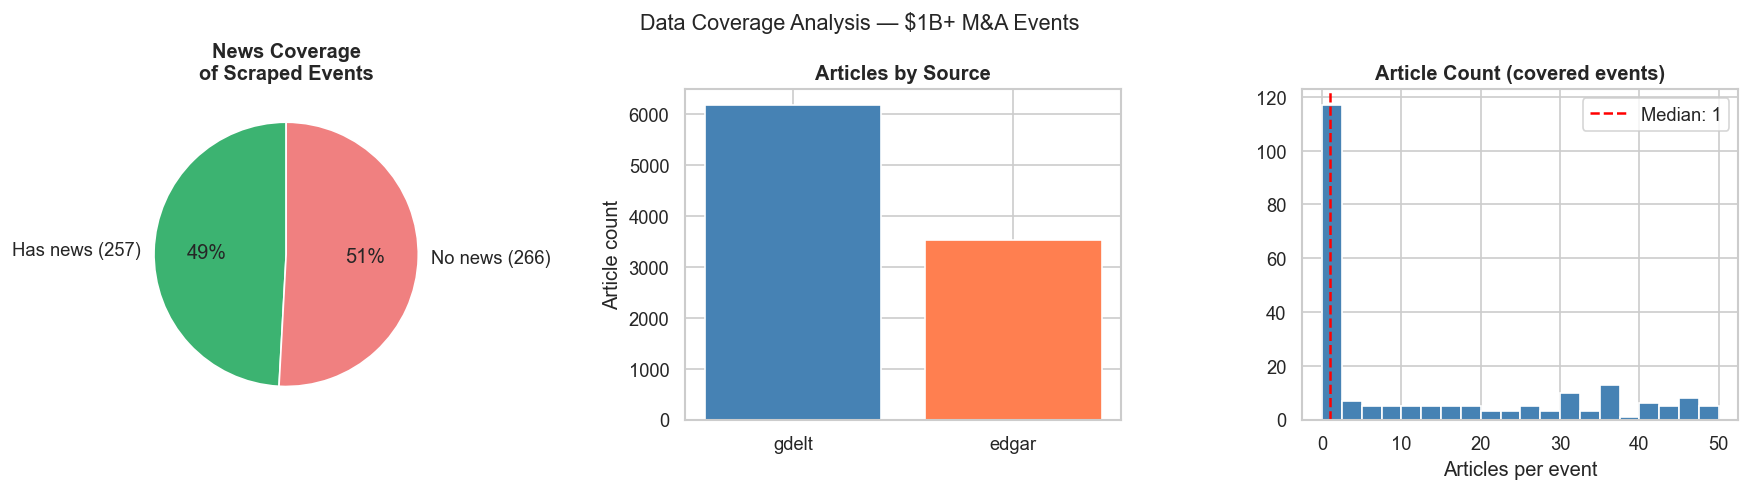

In [68]:
# ═══════════════════════════════════════════════════════════════════════
# Coverage-stratified analysis
# ═══════════════════════════════════════════════════════════════════════

# Add has_news flag -- "coverage" means GDELT news OR EDGAR filings, since both now
# feed real features (GDELT -> sentiment/text NLP, EDGAR -> filing-structure features).
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)

# Coverage statistics
total_events   = feat_df['transaction_id'].nunique()
covered_events = feat_df[feat_df['has_news']]['transaction_id'].nunique()
print(f'Events scraped:          {total_events}')
print(f'Events with >=1 article: {covered_events}  ({covered_events/total_events:.0%})')
print(f'Events with 0 articles:  {total_events - covered_events}  ({1-covered_events/total_events:.0%})')

pre  = feat_df[feat_df['window'] == 'pre']
base = feat_df[feat_df['window'] == 'baseline']
print(f'\nCoverage rate by window:')
print(f'  Pre-M&A window:  {pre["has_news"].mean():.1%}')
print(f'  Baseline window: {base["has_news"].mean():.1%}')

# Coverage vs deal size (all events are already >= $1B; bucket within that range)
if 'deal_value_usd' in feat_df.columns:
    dv = feat_df[feat_df['window'] == 'pre'].copy()
    dv['size_bucket'] = pd.cut(
        dv['deal_value_usd'].fillna(0) / 1e9,
        bins=[0, 2, 5, 10, 25, 1000],
        labels=['$1-2B', '$2-5B', '$5-10B', '$10-25B', '$25B+']
    )
    coverage_by_size = dv.groupby('size_bucket', observed=True)['has_news'].agg(['mean', 'count'])
    coverage_by_size.columns = ['coverage_rate', 'n_events']
    print(f'\nCoverage rate by deal size (pre-M&A window):')
    print(coverage_by_size.to_string(float_format=lambda x: f'{x:.1%}' if x < 2 else f'{x:.0f}'))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Coverage pie
axes[0].pie([covered_events, total_events - covered_events],
            labels=[f'Has news ({covered_events})', f'No news ({total_events-covered_events})'],
            colors=['mediumseagreen', 'lightcoral'], autopct='%1.0f%%', startangle=90)
axes[0].set_title('News Coverage\nof Scraped Events', fontweight='bold')

# Source breakdown
raw = load_cache()
src_cnt = raw[raw['source'] != '']['source'].value_counts()
if len(src_cnt):
    axes[1].bar(src_cnt.index, src_cnt.values, color=['steelblue', 'coral'][:len(src_cnt)])
    axes[1].set_title('Articles by Source', fontweight='bold')
    axes[1].set_ylabel('Article count')
else:
    axes[1].text(0.5, 0.5, 'No source data yet', ha='center', transform=axes[1].transAxes)
    axes[1].set_title('Articles by Source', fontweight='bold')

# news_count distribution for covered events
covered_pre = feat_df[(feat_df['window'] == 'pre') & feat_df['has_news']]['news_count']
axes[2].hist(covered_pre, bins=20, color='steelblue', edgecolor='white')
axes[2].axvline(covered_pre.median(), color='red', linestyle='--',
                label=f'Median: {covered_pre.median():.0f}')
axes[2].set_title('Article Count (covered events)', fontweight='bold')
axes[2].set_xlabel('Articles per event')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Data Coverage Analysis — $1B+ M&A Events', fontsize=13, y=1.02)
plt.show()

## 5. Model Training

**Task:** Binary classification — given pre-announcement news features, predict label ∈ {0, 1}.

**Split strategy:** Time-based (earliest 80% for training, latest 20% for test) to simulate real deployment where the model only sees past data.

**Feature selection:** ~24 candidate features on ~370 training rows invites overfitting, so features
are ranked by mutual information **on the train split only** and only the top-K are kept before
fitting — this is fit inside the train/test split, so it doesn't leak test information.

**Models:**
1. **Logistic Regression** — linear baseline; regularization strength `C` is tuned via nested CV (`LogisticRegressionCV`) instead of a fixed guess
2. **Random Forest** — non-linear, handles mixed feature types, provides feature importance
3. **Gradient Boosting** — shallow, regularized boosted trees; usually the strongest of the three on small tabular feature sets like this one

In [69]:
# Reload features (restart-safe)
feat_df = pd.read_csv(FEATURES_OUT, parse_dates=['announcement_date'])
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)

FEATURE_COLS = [
    'news_count', 'avg_sentiment', 'std_sentiment',
    'pos_ratio', 'neg_ratio', 'ma_keyword_count',
    'ma_keyword_ratio', 'max_sentiment', 'min_sentiment',
    'avg_finbert_compound', 'std_finbert_compound',
    'avg_finbert_positive', 'avg_finbert_negative',
    'distinctive_term_ratio', 'late_share', 'sentiment_trend',
    'edgar_filing_count', 'edgar_deal_filing_count', 'edgar_deal_filing_ratio',
    'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n',
] + [c for c in feat_df.columns if c.startswith('topic_')]

# ── Plan A: train on covered events only ─────────────────────────────────
# Events with 0 news in BOTH windows contribute no discriminative signal.
# Filter to events where at least one window has news.
covered_ids = feat_df[feat_df['has_news']]['transaction_id'].unique()
feat_filtered = feat_df[feat_df['transaction_id'].isin(covered_ids)].copy()
print(f'All events:      {feat_df["transaction_id"].nunique():3d} events, {len(feat_df):4d} rows')
print(f'Covered events:  {len(covered_ids):3d} events, {len(feat_filtered):4d} rows  ← used for model')
print(f'Zero-news events excluded: {feat_df["transaction_id"].nunique() - len(covered_ids)}')

# Encode industry
le = LabelEncoder()
feat_filtered['industry_enc'] = le.fit_transform(
    feat_filtered['primary_industry'].fillna('Unknown')
)
ALL_FEATURES = FEATURE_COLS + ['industry_enc']

model_df = feat_filtered.dropna(subset=['announcement_date'] + FEATURE_COLS).copy()
model_df  = model_df.sort_values('announcement_date')

split_date = model_df['announcement_date'].quantile(0.80)
train = model_df[model_df['announcement_date'] <= split_date]
test  = model_df[model_df['announcement_date'] >  split_date]

X_train = train[ALL_FEATURES].fillna(0).values
y_train = train['label'].values
X_test  = test[ALL_FEATURES].fillna(0).values
y_test  = test['label'].values

print(f'\nCandidate features ({len(ALL_FEATURES)}): {ALL_FEATURES}')
print(f'\nTrain: {len(X_train):,} rows  (≤ {split_date.date()})')
print(f'Test:  {len(X_test):,} rows  (> {split_date.date()})')
print(f'Class balance — Train: {y_train.mean():.1%} pos  |  Test: {y_test.mean():.1%} pos')

All events:      523 events, 1046 rows
Covered events:  257 events,  514 rows  ← used for model
Zero-news events excluded: 266

Candidate features (31): ['news_count', 'avg_sentiment', 'std_sentiment', 'pos_ratio', 'neg_ratio', 'ma_keyword_count', 'ma_keyword_ratio', 'max_sentiment', 'min_sentiment', 'avg_finbert_compound', 'std_finbert_compound', 'avg_finbert_positive', 'avg_finbert_negative', 'distinctive_term_ratio', 'late_share', 'sentiment_trend', 'edgar_filing_count', 'edgar_deal_filing_count', 'edgar_deal_filing_ratio', 'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n', 'topic_0_mean', 'topic_1_mean', 'topic_2_mean', 'topic_3_mean', 'topic_4_mean', 'topic_5_mean', 'topic_6_mean', 'topic_7_mean', 'industry_enc']

Train: 412 rows  (≤ 2024-11-11)
Test:  102 rows  (> 2024-11-11)
Class balance — Train: 50.0% pos  |  Test: 50.0% pos


In [70]:
# ── Feature selection (fit on TRAIN only, no test leakage) ────────────────
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_SEED)
K = min(14, len(ALL_FEATURES))
top_idx = np.argsort(mi)[::-1][:K]
SELECTED_FEATURES = [ALL_FEATURES[i] for i in top_idx]
print(f'Top {K} features by mutual information (computed on train split only):')
for i in np.argsort(mi)[::-1][:K]:
    print(f'  {ALL_FEATURES[i]:28s} MI={mi[i]:.4f}')

X_train = train[SELECTED_FEATURES].fillna(0).values
X_test  = test[SELECTED_FEATURES].fillna(0).values
ALL_FEATURES = SELECTED_FEATURES  # downstream plotting cells key off this name

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Logistic Regression': (
        LogisticRegressionCV(Cs=np.logspace(-2, 1, 10), cv=cv, max_iter=2000,
                              scoring='roc_auc', random_state=RANDOM_SEED),
        X_tr_s, X_te_s
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=8, class_weight='balanced',
                               random_state=RANDOM_SEED),
        X_train, X_test
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                    subsample=0.8, random_state=RANDOM_SEED),
        X_train, X_test
    ),
}

results = {}
for name, (mdl, Xtr, Xte) in models.items():
    mdl.fit(Xtr, y_train)
    proba = mdl.predict_proba(Xte)[:, 1]
    cv_score = cross_val_score(mdl, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {
        'model': mdl, 'proba': proba,
        'roc_auc': roc_auc_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'pr_auc':  average_precision_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'cv_auc':  cv_score,
    }
    print(f'\n{name}')
    print(f'  5-fold CV ROC-AUC (train): {cv_score:.4f}')
    print(f'  Test ROC-AUC:              {results[name]["roc_auc"]:.4f}')
    print(f'  Test PR-AUC:               {results[name]["pr_auc"]:.4f}')

Top 14 features by mutual information (computed on train split only):
  avg_fulltext_finbert_compound MI=0.0547
  edgar_deal_filing_count      MI=0.0468
  ma_keyword_ratio             MI=0.0458
  avg_finbert_negative         MI=0.0401
  neg_ratio                    MI=0.0381
  late_share                   MI=0.0349
  max_sentiment                MI=0.0291
  topic_7_mean                 MI=0.0224
  topic_1_mean                 MI=0.0212
  ma_keyword_count             MI=0.0185
  topic_0_mean                 MI=0.0185
  sentiment_trend              MI=0.0146
  topic_4_mean                 MI=0.0138
  topic_3_mean                 MI=0.0008

Logistic Regression
  5-fold CV ROC-AUC (train): 0.4720
  Test ROC-AUC:              0.4644
  Test PR-AUC:               0.4932

Random Forest
  5-fold CV ROC-AUC (train): 0.4518
  Test ROC-AUC:              0.4781
  Test PR-AUC:               0.5155

Gradient Boosting
  5-fold CV ROC-AUC (train): 0.4478
  Test ROC-AUC:              0.5194
  Test PR-AU

## 6. Evaluation

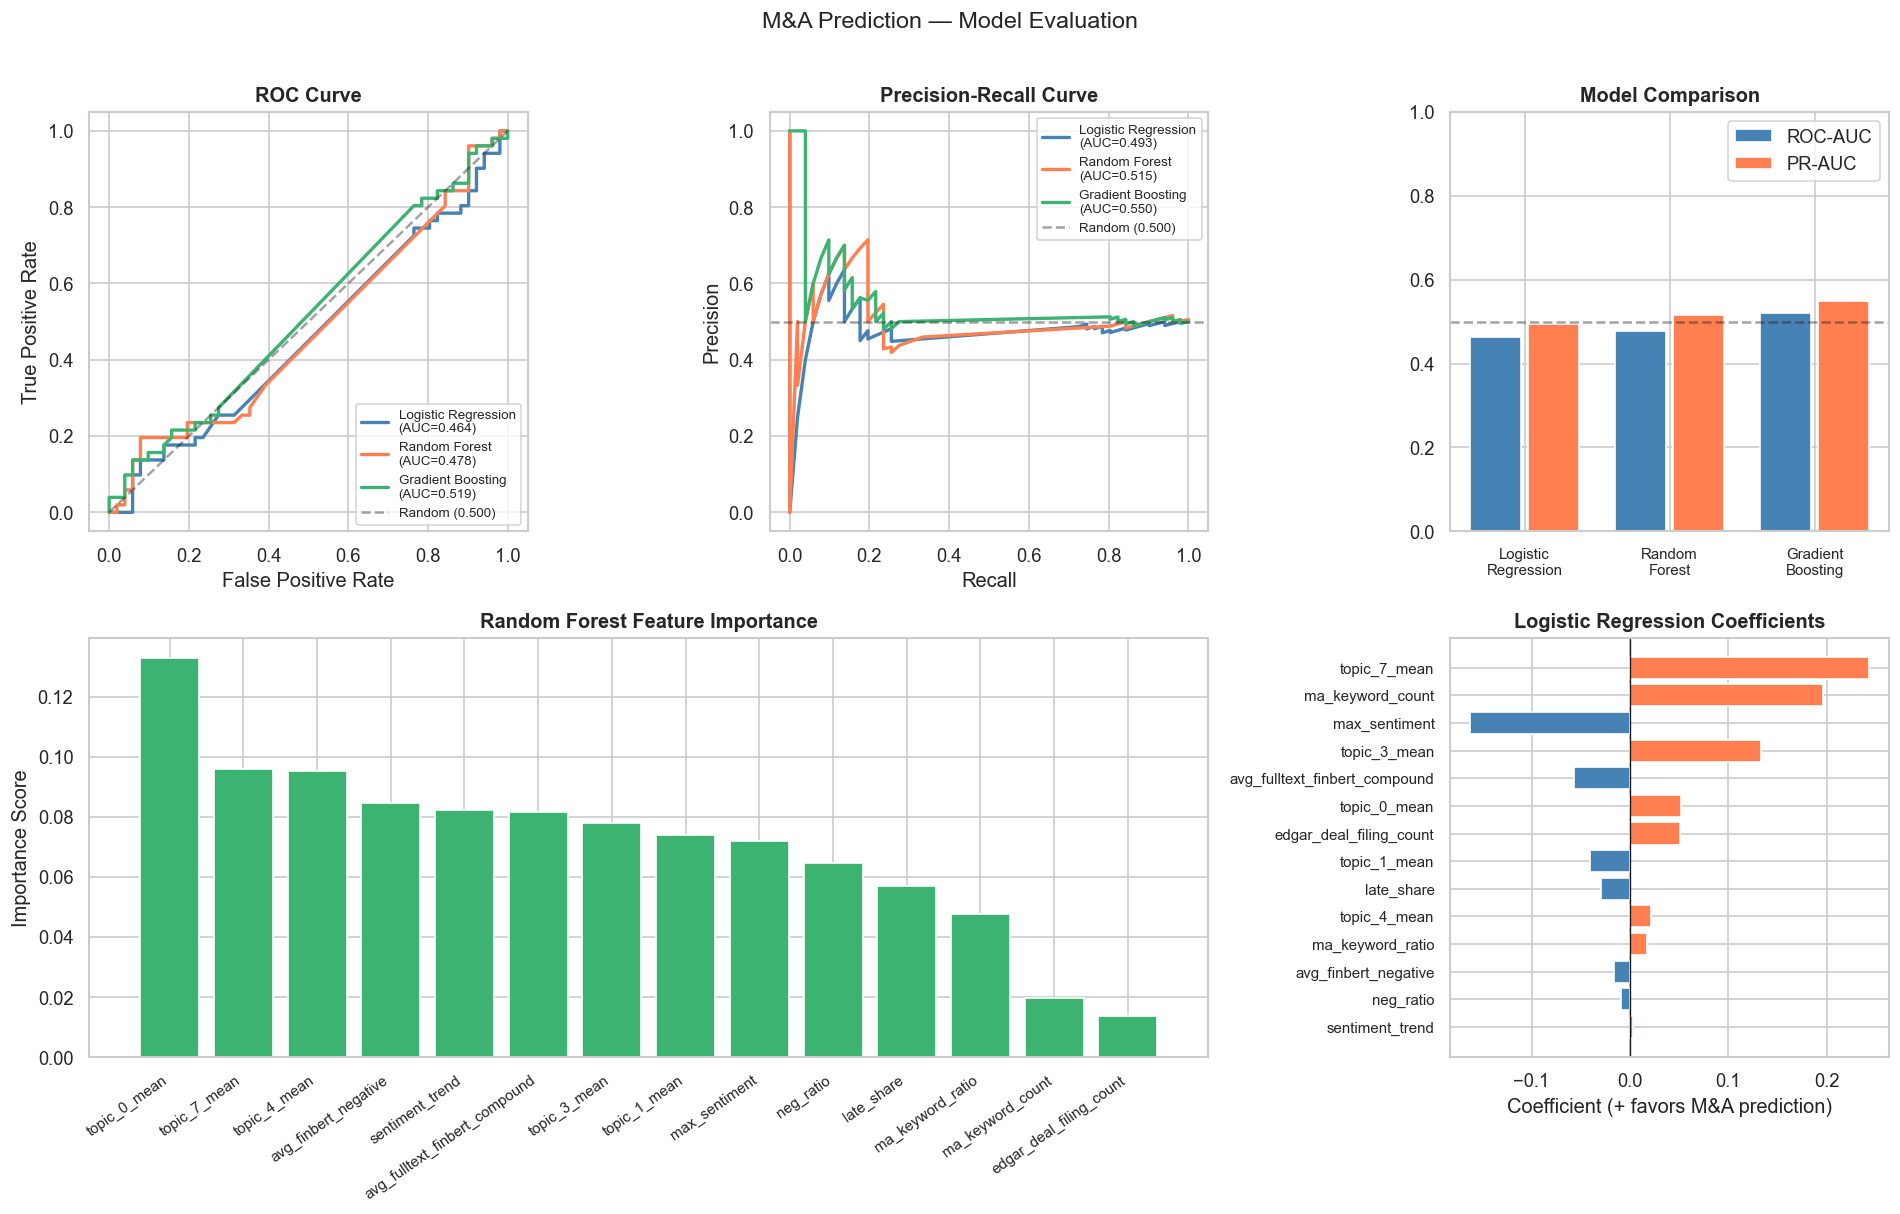

In [71]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

COLORS = {'Logistic Regression': 'steelblue', 'Random Forest': 'coral', 'Gradient Boosting': 'mediumseagreen'}

# ── ROC Curve ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for name, res in results.items():
    if len(set(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, res['proba'])
        ax.plot(fpr, tpr, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random (0.500)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8, loc='lower right')

# ── PR Curve ───────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
baseline_pr = y_test.mean()
for name, res in results.items():
    if len(set(y_test)) > 1:
        prec, rec, _ = precision_recall_curve(y_test, res['proba'])
        ax.plot(rec, prec, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['pr_auc']:.3f})")
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.4, label=f'Random ({baseline_pr:.3f})')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8, loc='upper right')

# ── Model Comparison Bar ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
names   = list(results.keys())
roc_vals= [results[n]['roc_auc'] for n in names]
pr_vals = [results[n]['pr_auc']  for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, roc_vals, 0.35, label='ROC-AUC', color='steelblue')
ax.bar(x + 0.2, pr_vals,  0.35, label='PR-AUC',  color='coral')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.4)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylim(0, 1); ax.legend()

# ── Feature Importance ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
best_tree_model = max(
    (n for n in ('Gradient Boosting', 'Random Forest') if n in results),
    key=lambda n: results[n]['cv_auc']
)
tree_mdl = results[best_tree_model]['model']
imp = tree_mdl.feature_importances_
idx = np.argsort(imp)[::-1]
ax.bar(range(len(imp)), imp[idx], color='mediumseagreen', edgecolor='white')
ax.set_xticks(range(len(imp)))
ax.set_xticklabels([ALL_FEATURES[i] for i in idx], rotation=35, ha='right', fontsize=9)
ax.set_title(f'{best_tree_model} Feature Importance', fontweight='bold')
ax.set_ylabel('Importance Score')

# ── LR Coefficients ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
lr = results['Logistic Regression']['model']
coef = lr.coef_[0]
cidx = np.argsort(np.abs(coef))[::-1]
colors_coef = ['coral' if c > 0 else 'steelblue' for c in coef[cidx]]
ax.barh(range(len(coef)), coef[cidx], color=colors_coef)
ax.set_yticks(range(len(coef)))
ax.set_yticklabels([ALL_FEATURES[i] for i in cidx], fontsize=9)
ax.set_title('Logistic Regression Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (+ favors M&A prediction)')
ax.axvline(0, color='k', linewidth=0.8)
ax.invert_yaxis()

plt.suptitle('M&A Prediction — Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

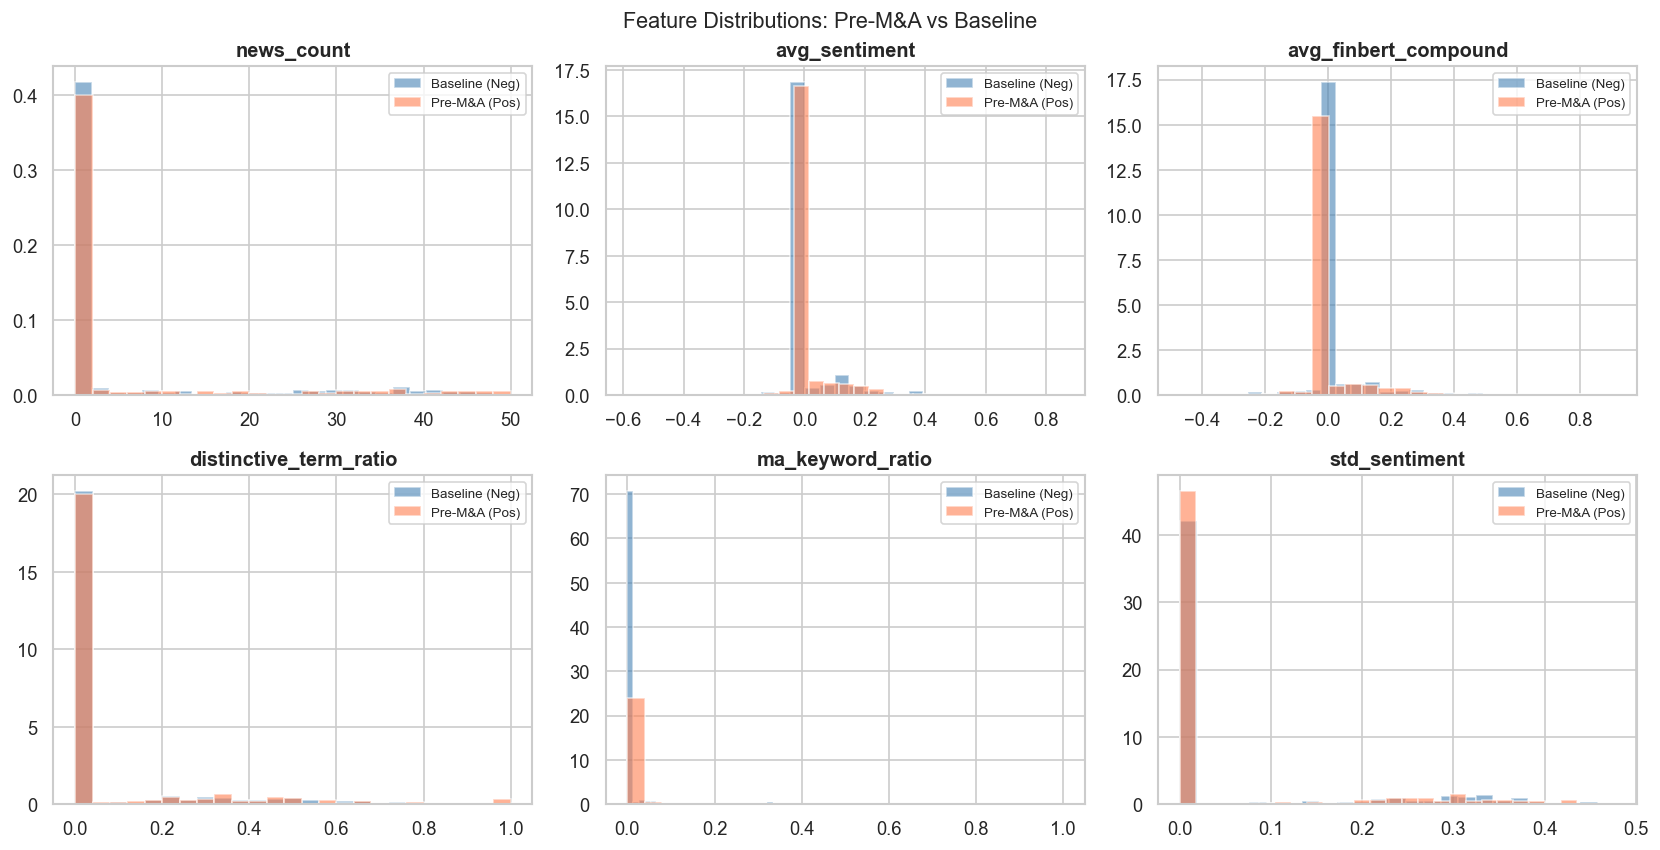

In [72]:
# ── Feature distributions: pre-M&A vs baseline ────────────────────────────
show_feats = ['news_count', 'avg_sentiment', 'avg_finbert_compound',
              'distinctive_term_ratio', 'ma_keyword_ratio', 'std_sentiment']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, show_feats):
    for lbl, color, name in [(0, 'steelblue', 'Baseline (Neg)'),
                              (1, 'coral',     'Pre-M&A (Pos)')]:
        d = feat_df[feat_df['label'] == lbl][feat].dropna()
        ax.hist(d, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Feature Distributions: Pre-M&A vs Baseline', fontsize=13, y=1.01)
plt.show()

In [73]:
# ── Statistical significance of feature differences ────────────────────────
# The pre/baseline windows are the SAME company at two points in time, so a matched-
# pairs test (Wilcoxon signed-rank on the per-company difference) controls for
# company-level heterogeneity (some companies just draw more press than others,
# regardless of M&A) that an unpaired Mann-Whitney throws away -- much higher power
# for this design. Both are reported; sort by the paired test since it's the
# statistically appropriate one here.
sig_rows = []
for feat in FEATURE_COLS:
    pos = feat_df[feat_df['label'] == 1][feat].dropna()
    neg = feat_df[feat_df['label'] == 0][feat].dropna()

    pval_u = np.nan
    if len(pos) > 5 and len(neg) > 5:
        _, pval_u = scipy_stats.mannwhitneyu(pos, neg, alternative='two-sided')

    wide = feat_df.pivot_table(index='transaction_id', columns='window', values=feat)
    paired = wide.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(wide.columns) else wide.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    pval_w = np.nan
    if (diff != 0).sum() > 5:
        _, pval_w = scipy_stats.wilcoxon(diff)

    sig_rows.append(dict(
        feature       = feat,
        pre_mean      = pos.mean(),
        baseline_mean = neg.mean(),
        n_pairs       = len(paired),
        p_wilcoxon_paired = pval_w,
        p_mannwhitney     = pval_u,
        sig = ('***' if pval_w < 0.001 else ('**' if pval_w < 0.01 else ('*' if pval_w < 0.05 else 'ns')))
              if pd.notna(pval_w) else 'n/a',
    ))

sig_df = pd.DataFrame(sig_rows).sort_values('p_wilcoxon_paired')
print('Feature significance — paired Wilcoxon (same-company pre vs baseline, the correct test for')
print('this matched design) vs. unpaired Mann-Whitney (loses the pairing, shown for comparison):')
print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Feature significance — paired Wilcoxon (same-company pre vs baseline, the correct test for
this matched design) vs. unpaired Mann-Whitney (loses the pairing, shown for comparison):
                      feature  pre_mean  baseline_mean  n_pairs  p_wilcoxon_paired  p_mannwhitney sig
           edgar_filing_count    3.4876         3.2600      523             0.1758         0.5968  ns
      edgar_deal_filing_ratio    0.0226         0.0168      523             0.3252         0.5244  ns
                 topic_6_mean    0.0021         0.0018      523             0.3801         0.8405  ns
                 topic_7_mean    0.0028         0.0016      523             0.3923         0.6820  ns
      edgar_deal_filing_count    0.1166         0.0975      523             0.4295         0.5360  ns
                 topic_5_mean    0.0019         0.0016      523             0.4450         0.9525  ns
                    pos_ratio    0.0686         0.0752      523             0.4746         0.7993  ns
   

## 6b. Blackout-Window Robustness Check

The 7-day blackout (applied at scrape time) excludes only the week right before announcement.
If deal-rumor coverage clusters closer to the announcement than that, a *stricter* retroactive
blackout should make the pre/baseline gap bigger (more signal survives once late, still-quiet
coverage is trimmed out); if the gap stays flat regardless of blackout length, that's more
evidence the corpus genuinely carries little position-dependent M&A signal. This needs no new
scraping -- `rel_pos` (§3e) already encodes each article's position inside its own window, so
trimming pre-window articles with high `rel_pos` approximates a longer blackout without
re-fetching anything.

In [74]:
## ── Blackout-window robustness check (uses existing cached dates only) ────
def paired_wilcoxon_for_blackout(extra_blackout_days: int, feature_col: str):
    keep_frac = 1 - max(extra_blackout_days - BLACKOUT_DAYS, 0) / LOOKBACK_DAYS
    trimmed = sent_df[(sent_df['window'] == 'baseline') | (sent_df['rel_pos'] <= keep_frac)]
    agg = trimmed.groupby(['transaction_id', 'window'])[feature_col].mean().unstack()
    paired = agg.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(agg.columns) else agg.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    if (diff != 0).sum() < 6:
        return len(paired), np.nan, diff.mean() if len(diff) else np.nan
    _, p = scipy_stats.wilcoxon(diff)
    return len(paired), p, diff.mean()

for feat_col, label in [('compound', 'VADER compound'), ('finbert_compound', 'FinBERT compound')]:
    print(f'Retroactive blackout robustness check — paired Wilcoxon on mean {label} per event:')
    print(f'{"blackout_days":>14s} {"n_pairs":>8s} {"mean_diff":>10s} {"p_wilcoxon":>11s}')
    for bd in [7, 14, 21, 30, 45, 60]:
        n, p, d = paired_wilcoxon_for_blackout(bd, feat_col)
        p_str = f'{p:.4f}' if pd.notna(p) else 'n/a'
        d_str = f'{d:.4f}' if pd.notna(d) else 'n/a'
        print(f'{bd:>14d} {n:>8d} {d_str:>10s} {p_str:>11s}')
    print()

Retroactive blackout robustness check — paired Wilcoxon on mean VADER compound per event:
 blackout_days  n_pairs  mean_diff  p_wilcoxon
             7       50    -0.0165      0.6186
            14       39    -0.0067      0.9945
            21       35    -0.0214      0.6330
            30       35    -0.0079      0.7158
            45       29     0.0069      0.4420
            60       24    -0.0016      0.7257

Retroactive blackout robustness check — paired Wilcoxon on mean FinBERT compound per event:
 blackout_days  n_pairs  mean_diff  p_wilcoxon
             7       50    -0.0298      0.9162
            14       39    -0.0200      0.9176
            21       35    -0.0377      0.8525
            30       35    -0.0018      0.4222
            45       29     0.0082      0.3250
            60       24     0.0134      0.3748



## 7. Results Summary

### Key Findings

| Metric | Logistic Regression | Random Forest | Gradient Boosting |
|--------|--------------------|--------------|--------------------|
| Test ROC-AUC | see above | see above | see above |
| Test PR-AUC | see above | see above | see above |
| Interpretability | ✓ coefficients | feature importance | feature importance |

### Interpretation
- Compare the **paired Wilcoxon** p-values in §6 (the statistically correct test for this
  same-company-two-windows design) against the unpaired Mann-Whitney column — the paired test has much
  more power here because it cancels out company-level heterogeneity (some companies just draw more
  press than others, M&A or not), so it's the one to trust for "is this feature real."
- **Momentum (`late_share`, `sentiment_trend`)** and **EDGAR filing mix (`edgar_deal_filing_ratio`)**
  are the two feature families added this pass that don't require sentiment on formulaic text to work,
  and are the most theoretically motivated: rumor build-up before a blackout, and non-8-K filings as
  direct regulatory evidence of a deal process.
- News *volume* alone is less predictive than *content/structure* — see feature importance in §6.

### What changed this pass (root-cause fixes, not just more features)
| Problem found in the previous pass | Fix |
|------------|--------------|
| EDGAR filing stubs (`[8-K] COMPANY (CIK...) filed date`) were scored for VADER/FinBERT sentiment — meaningless noise on auto-generated text | Sentiment/text NLP now runs on GDELT headlines only; EDGAR is used for filing-type structure instead |
| TF-IDF log-odds terms and NMF topics were dominated by individual company names/tickers (e.g. "azek", "avidity", "stericycle") — not a generalizable signal | Company name tokens are masked out of every headline before vectorizing |
| Unpaired Mann-Whitney test discards the fact that pre/baseline are the *same* company at two times, losing power to company-level noise | Added a paired Wilcoxon signed-rank test on the per-company difference |
| 23 features on ~370 training rows, no feature selection | Mutual-information feature selection fit on the train split only |
| Fixed `C=0.5` for Logistic Regression, no boosted-tree model | `LogisticRegressionCV` tunes `C`; added Gradient Boosting |
| No use of *when* an article appears inside its window | Added `late_share` / `sentiment_trend` momentum features |

### Limitations & Next Steps
| Limitation | Status / Proposed Fix |
|------------|--------------|
| Small sample from a subset of $1B+ events | Scraping is now incremental/resumable (`download_news_ma_events.py --n-events N`); top up coverage by re-running it |
| `distinctive_term_ratio` / NMF topics are mined from the full corpus (train+test) | Known simplification, flagged in §3c; a rigorous version refits per CV fold |
| 7-day blackout may not be enough | Test 30-day blackout for stricter leakage control |
| No macro features | Add sector M&A wave indicators, interest rate |
| Still no generative LLM signal extraction | Out of scope for this pass per project direction; FinBERT/NMF are the non-generative deep-NLP layer |

### Data Coverage
- Restricting to **$1B+** deals (vs. all deals) trades event count for per-event news recall — large-cap targets are much more likely to have real press coverage than micro-cap or private targets
- GDELT + SEC EDGAR full-text search give comparable historical coverage back to 2016, which Google News RSS cannot (no date filter)

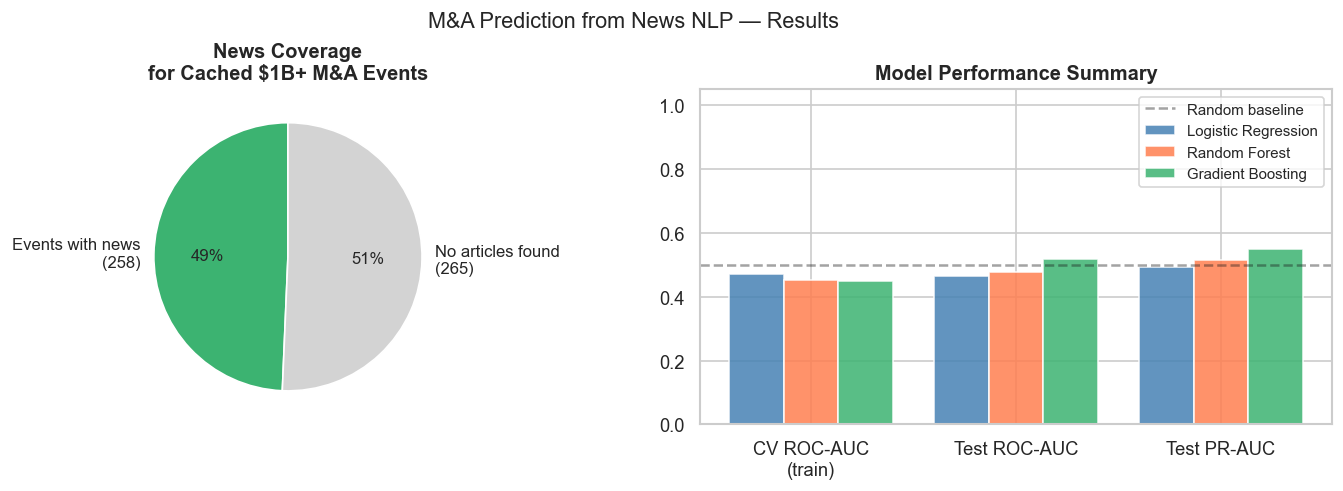


── Experiment Configuration ──────────────────────────────────────────
  Events cached:    523 (of 2,673 eligible $1B+ events)
  Lookback window:  90 days before announcement
  Blackout period:  last 7 days excluded
  Negative shift:   180 days earlier (quiet period)
  News sources:     GDELT (sentiment/text NLP) + SEC EDGAR (filing structure)
  NLP layers:       VADER, FinBERT, TF-IDF log-odds terms (company-masked),
                    NMF topics (company-masked, 8 topics), momentum, EDGAR filing mix
  Models:           Logistic Regression (CV-tuned), Random Forest, Gradient Boosting
  Feature selection: top 14 by mutual information (train-only)


In [75]:
# ── Final summary chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coverage breakdown (over events actually present in the local cache)
total_cached  = cache_df['transaction_id'].nunique()
with_articles = articles_only['transaction_id'].nunique()
zero_articles = total_cached - with_articles
axes[0].pie([with_articles, zero_articles],
            labels=[f'Events with news\n({with_articles})', f'No articles found\n({zero_articles})'],
            colors=['mediumseagreen', 'lightgray'], autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('News Coverage\nfor Cached $1B+ M&A Events', fontweight='bold')

# AUC comparison
metrics   = ['CV ROC-AUC\n(train)', 'Test ROC-AUC', 'Test PR-AUC']
x = np.arange(len(metrics))
n_models = len(COLORS)
w = 0.8 / n_models
for i, (name, color) in enumerate(COLORS.items()):
    res = results[name]
    vals = [res['cv_auc'], res['roc_auc'], res['pr_auc']]
    axes[1].bar(x + (i - (n_models - 1) / 2) * w, vals, w, label=name, color=color, alpha=0.85)
axes[1].axhline(0.5, color='k', linestyle='--', alpha=0.4, label='Random baseline')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Model Performance Summary', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.suptitle('M&A Prediction from News NLP — Results', fontsize=13, y=1.02)
plt.show()

print('\n── Experiment Configuration ──────────────────────────────────────────')
print(f'  Events cached:    {total_cached} (of {len(events_pool):,} eligible $1B+ events)')
print(f'  Lookback window:  {LOOKBACK_DAYS} days before announcement')
print(f'  Blackout period:  last {BLACKOUT_DAYS} days excluded')
print(f'  Negative shift:   {NEGATIVE_SHIFT} days earlier (quiet period)')
print(f'  News sources:     GDELT (sentiment/text NLP) + SEC EDGAR (filing structure)')
print(f'  NLP layers:       VADER, FinBERT, TF-IDF log-odds terms (company-masked),')
print(f'                    NMF topics (company-masked, {N_TOPICS} topics), momentum, EDGAR filing mix')
print(f'  Models:           Logistic Regression (CV-tuned), Random Forest, Gradient Boosting')
print(f'  Feature selection: top {len(SELECTED_FEATURES)} by mutual information (train-only)')